###### 前章のCBOWモデルでは、語彙数がある程度増えると計算にあまりにも多くの時間がかかってしまう
###### → 前章のCBOWモデルを高速化する
###### ・Embeddingレイヤの導入
###### ・Negative Sampling という新しい損失関数の導入

####
##### Embeddingレイヤ
###### 入力層のone-hot表現と重み行列$W_in$の積による計算 のボトルネックを解決する
######
###### 単語の語彙数が100万とすると、one-hot表現の次元数も100万になってしまう
$$\begin{pmatrix} 0 & 1 & ... & 0  \end{pmatrix}　\begin{pmatrix} ○ & ○ \\ ○ & ● \\ : & : \end{pmatrix} = \begin{pmatrix} ○ & ●  \end{pmatrix}$$
###### $ \hspace{55mm} c \hspace{25mm} W_{in} \hspace{7mm} = \hspace{8mm} h$
###### 行列の乗算をするのではなく、重みパラメータから「単語IDに該当する行（ベクトル）」を抜き出す。このためのレイヤをEmbeddingレイヤと呼ぶ。

In [33]:
import numpy as np
W = np.arange(21).reshape(7,3)
W

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14],
       [15, 16, 17],
       [18, 19, 20]])

In [35]:
W[2]

array([6, 7, 8])

In [37]:
# 複数の行をまとめて抽出
idx = np.array([1,0,3,0])
W[idx]

array([[ 3,  4,  5],
       [ 0,  1,  2],
       [ 9, 10, 11],
       [ 0,  1,  2]])

####
##### Negative Sampling（負例サンプリング）
###### 中間層と重み行列$W_{out}$の積およびSoftmaxレイヤの計算 のボトルネックを解決する
######
###### 「多値分類」の問題を「二値分類」の問題に近似する
###### 全ての単語を対象に計算を行うのではなく、ある単語だけに着目する
###### 「コンテキストがyouとgoodbyeのとき、ターゲットはsayですか？」という質問にyes/Noで答えるニューラルネットワークを考える
######
###### スコアを確率に変換するためにシグモイド関数を、損失を求めるために交差エントロピー誤差を用いる
###### $$ シグモイド関数：y = \frac{1}{1 + exp(-x)}$$
###### $$ 交差エントロピー誤差：L = -(t*logy + (1-t)*log(1-y))$$
###### 正解ラベル$t$はYesで1、Noで0
###### tが1のときは$-logy$が出力され、tが0のときは$-log(1-y)$が出力される
#####
###### 正例をターゲットとした場合の損失だけでなく、負例をいくつかサンプリングし、その負例に対しても同様に損失を求める。これらを足し合わせ、その結果を最終的な損失とする。
###### 負例は、コーパスの統計データに基づいてサンプリングし、高頻出な単語を抽出されやすくする。

In [56]:
# 0-9の数字の中からランダムにサンプリング
np.random.choice(10)

5

In [58]:
# wordsから一つだけランダムにサンプリング
words = ['you','say','goodbye','I','hello','.']
np.random.choice(words)

np.str_('you')

In [62]:
# 5つだけランダムにサンプリング（重複あり）
np.random.choice(words, size=5)

array(['.', 'hello', 'you', 'hello', 'hello'], dtype='<U7')

In [60]:
# 5つだけランダムにサンプリング（重複なし）
np.random.choice(words, size=5, replace=False)

array(['.', 'goodbye', 'I', 'you', 'say'], dtype='<U7')

In [72]:
# 確率分布に従ってサンプリング
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
np.random.choice(words, p=p)

np.str_('you')

####
###### ch04/train.pyの実行結果
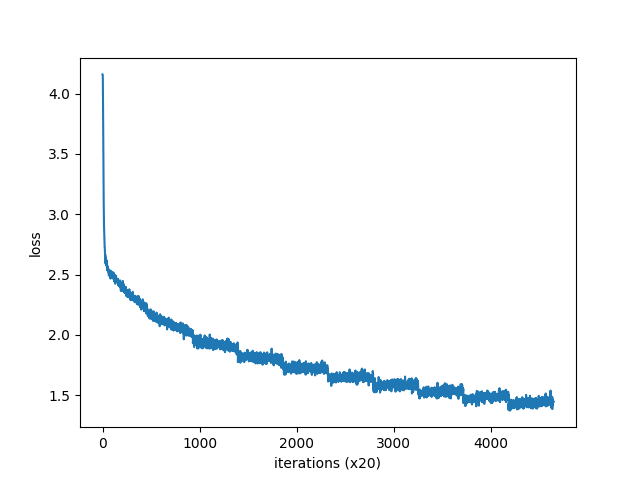

In [ ]:
(old_env) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch04/eval.py 

[query] you
 i: 0.75732421875
 we: 0.7177734375
 your: 0.61767578125
 anybody: 0.61181640625
 they: 0.595703125

[query] year
 month: 0.82470703125
 summer: 0.7685546875
 week: 0.76513671875
 spring: 0.75634765625
 decade: 0.69775390625

[query] car
 auto: 0.63427734375
 truck: 0.62060546875
 luxury: 0.61474609375
 window: 0.61376953125
 merkur: 0.60205078125

[query] toyota
 honda: 0.6875
 nissan: 0.64501953125
 tires: 0.6328125
 engines: 0.630859375
 nec: 0.6142578125
--------------------------------------------------

[analogy] king:man = queen:?
 a.m: 6.02734375
 naczelnik: 5.1640625
 woman: 5.15234375
 mother: 4.91015625
 cubans: 4.7421875

[analogy] take:took = go:?
 came: 4.2890625
 went: 4.15625
 're: 4.0546875
 were: 3.951171875
 goes: 3.89453125

[analogy] car:cars = child:?
 children: 5.328125
 rape: 5.21875
 a.m: 5.17578125
 incest: 5.1015625
 adults: 4.59765625

[analogy] good:better = bad:?
 less: 5.53515625
 more: 5.453125
 rather: 5.37890625
 greater: 4.16015625
 faster: 4.09765625

####
##### 単語の類似性の評価
###### 人間が作成した単語類似どの評価セットを使って評価することが多い
###### 人が出したスコアとword2vecによるコサイン類似度のスコアを比較して、その相関性を見る